# 05 — ARIMA Model (Statistical Baseline)

---

## Why ARIMA?

ARIMA (Auto-Regressive Integrated Moving Average) is a classical time series
model that captures **linear autoregressive patterns** in the return series.

| Aspect | ARIMA | XGBoost/LSTM |
|--------|-------|-------------|
| Input | Univariate returns | 50+ engineered features |
| Training | Per-ticker | Pooled panel |
| Captures | Linear temporal dependencies | Non-linear feature interactions |
| Speed | Seconds | Minutes to hours |
| Correlation with ML | Very low | — |

By adding ARIMA to the ensemble, we get **diversification** from a fundamentally
different signal source. If ARIMA is uncorrelated with ML models but has >50%
direction accuracy, the ensemble Sharpe ratio improves even if ARIMA is a weaker
standalone model.

## Mathematical Foundation

$$ARIMA(p, d, q): \quad \phi(B)(1-B)^d X_t = \theta(B) \epsilon_t$$

Where:
- $p$ = autoregressive order (how many past returns influence today)
- $d$ = differencing order (0 for stationary returns, 1 for integrated series)
- $q$ = moving average order (how many past errors influence today)
- $B$ = backshift operator
- $\phi(B), \theta(B)$ = AR and MA polynomials

## Walk-Forward Protocol

Same expanding-window walk-forward as XGBoost/LightGBM:
- **Expanding** training window (always start from date 0)
- 5-day embargo between train and test
- 63-day (1 quarter) test windows
- ARIMA fitted per-ticker per fold

---
*Educational project. Not financial advice.*

In [5]:
import os, sys, gc, time
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, accuracy_score

from src.models.arima_model import ARIMAModel
from src.features.pipeline import FeaturePipeline
from src.utils.constants import *

plt.style.use("seaborn-v0_8-whitegrid")
gc.collect()
time.sleep(0.1)

print("✅ Setup complete")

✅ Setup complete


## Step 1 — Load Processed Data

In [6]:
# Load all processed data
processed_dir = DATA_DIR / "processed"
processed_files = sorted(processed_dir.glob("*.NS.parquet"))

all_data = {}
for f in processed_files:
    all_data[f.stem] = pd.read_parquet(f)

print(f"Loaded {len(all_data)} tickers")
sample_tickers = list(all_data.keys())
print(f"Training on {len(sample_tickers)} tickers")

Loaded 122 tickers
Training on 122 tickers


## Step 2 — Prepare Panel Data with Ticker Identity

Unlike tree models, ARIMA needs ticker identity preserved (per-ticker fitting).
We keep `_ticker` and `_date` columns in the panel.

In [7]:
target_horizon = 5  # 5-day return prediction

# Build panel with ticker identity
all_features = []
all_targets = []

for ticker in sample_tickers:
    df = all_data[ticker]
    
    # Create target: forward return
    target = df["Close"].shift(-target_horizon) / df["Close"] - 1
    valid = target.dropna().index
    
    if len(valid) > 200:
        feat_df = pd.DataFrame(index=valid)
        feat_df["_ticker"] = ticker
        feat_df["_date"] = valid
        feat_df["_close"] = df.loc[valid, "Close"]
        all_features.append(feat_df)
        all_targets.append(target.loc[valid])

X_all = pd.concat(all_features).reset_index(drop=True)
y_all = pd.concat(all_targets).reset_index(drop=True)

dates_col = X_all["_date"]
tickers_col = X_all["_ticker"]

# Sort by date
sort_order = dates_col.argsort()
X_all = X_all.iloc[sort_order].reset_index(drop=True)
y_all = y_all.iloc[sort_order].reset_index(drop=True)
dates_col = X_all["_date"]
tickers_col = X_all["_ticker"]

print(f"Total samples:  {len(X_all):,}")
print(f"Tickers:        {len(X_all['_ticker'].unique())}")
print(f"Date range:     {dates_col.min().date()} → {dates_col.max().date()}")
print(f"Target mean:    {y_all.mean():.4f}")
print(f"Target std:     {y_all.std():.4f}")

Total samples:  253,768
Tickers:        121
Date range:     2016-12-09 → 2026-02-04
Target mean:    0.0049
Target std:     0.0491


## Step 3 — Walk-Forward Training (Per-Ticker ARIMA)

For each fold:
1. Split data by calendar date (expanding window)
2. Fit ARIMA per-ticker on training returns
3. Forecast for each ticker in the test set
4. Record OOF predictions for ensemble stacking

In [8]:
unique_dates = sorted(dates_col.unique())
n_dates = len(unique_dates)

train_days = 504
test_days = 63
embargo_days = 5
step_days = 252  # ~1 year step → ~5 folds (practical for ARIMA's per-ticker fitting)

fold_results = []
fold_predictions = []
fold_num = 0

total_start = time.time()
idx = 0
while idx + train_days + embargo_days + test_days <= n_dates:
    fold_num += 1
    
    train_end_idx = idx + train_days
    test_start_idx = train_end_idx + embargo_days
    test_end_idx = test_start_idx + test_days
    
    if test_end_idx > n_dates:
        break
    
    # Expanding window
    train_dates_set = set(unique_dates[0:train_end_idx])
    test_dates_set = set(unique_dates[test_start_idx:test_end_idx])
    
    train_mask = dates_col.isin(train_dates_set)
    test_mask = dates_col.isin(test_dates_set)
    
    X_train = X_all[train_mask.values]
    y_train = y_all[train_mask.values]
    X_test = X_all[test_mask.values]
    y_test = y_all[test_mask.values]
    
    if len(X_train) < 200 or len(X_test) < 30:
        idx += step_days
        continue
    
    print(f"\n--- Fold {fold_num} ---")
    print(f"  Train: {unique_dates[0].date()} → {unique_dates[train_end_idx-1].date()} ({len(X_train):,} samples)")
    print(f"  Test:  {unique_dates[test_start_idx].date()} → {unique_dates[min(test_end_idx-1, n_dates-1)].date()} ({len(X_test):,} samples)")
    
    # Fit ARIMA per-ticker (with 60s timeout per ticker)
    fold_start = time.time()
    model = ARIMAModel()
    metrics = model.fit(X_train, y_train)
    fold_time = time.time() - fold_start
    print(f"  Fitted {metrics['fitted_tickers']}/{metrics['total_tickers']} tickers in {fold_time:.0f}s")
    
    # Predict
    y_pred = model.predict(X_test)
    
    # Metrics
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    direction_acc = accuracy_score(y_test > 0, y_pred > 0)
    
    fold_results.append({
        "fold": fold_num,
        "rmse": rmse,
        "mae": mae,
        "r2": r2,
        "direction_accuracy": direction_acc,
        "n_train": len(X_train),
        "n_test": len(X_test),
        "fitted_tickers": metrics['fitted_tickers'],
    })
    
    test_dates_vals = dates_col[test_mask.values]
    test_tickers_vals = tickers_col[test_mask.values]
    fold_predictions.append(pd.DataFrame({
        "date": test_dates_vals.values,
        "Ticker": test_tickers_vals.values,
        "actual": y_test.values,
        "predicted": y_pred,
        "fold": fold_num,
    }))
    
    print(f"  RMSE: {rmse:.4f}  MAE: {mae:.4f}  R²: {r2:.4f}  Dir Acc: {direction_acc:.1%}")
    
    idx += step_days
    gc.collect()

total_time = time.time() - total_start
results_df = pd.DataFrame(fold_results)
print(f"\n{'='*60}")
print(f"TOTAL TIME: {total_time/60:.1f} minutes")
print(f"AVERAGE ACROSS {len(fold_results)} FOLDS:")
print(f"  RMSE:              {results_df['rmse'].mean():.4f}  ± {results_df['rmse'].std():.4f}")
print(f"  MAE:               {results_df['mae'].mean():.4f}  ± {results_df['mae'].std():.4f}")
print(f"  R²:                {results_df['r2'].mean():.4f}  ± {results_df['r2'].std():.4f}")
print(f"  Direction Accuracy: {results_df['direction_accuracy'].mean():.1%}  ± {results_df['direction_accuracy'].std():.1%}")


--- Fold 1 ---
  Train: 2016-12-09 → 2018-12-20 (50,634 samples)
  Test:  2018-12-31 → 2019-04-02 (6,713 samples)
  Fitted 105/105 tickers in 327s
  RMSE: 0.0912  MAE: 0.0673  R²: -2.9070  Dir Acc: 52.2%

--- Fold 2 ---
  Train: 2016-12-09 → 2020-01-03 (77,738 samples)
  Test:  2020-01-13 → 2020-04-16 (6,893 samples)
  Fitted 108/108 tickers in 465s
  RMSE: 0.1393  MAE: 0.1010  R²: -1.5537  Dir Acc: 46.7%

--- Fold 3 ---
  Train: 2016-12-09 → 2021-01-06 (105,590 samples)
  Test:  2021-01-14 → 2021-04-19 (7,056 samples)
  Fitted 111/112 tickers in 604s
  RMSE: 0.1804  MAE: 0.1238  R²: -9.4720  Dir Acc: 49.3%

--- Fold 4 ---
  Train: 2016-12-09 → 2022-01-12 (134,112 samples)
  Test:  2022-01-20 → 2022-04-25 (7,298 samples)
  Fitted 114/115 tickers in 748s
  RMSE: 0.1208  MAE: 0.0899  R²: -4.4983  Dir Acc: 50.1%

--- Fold 5 ---
  Train: 2016-12-09 → 2023-01-17 (163,589 samples)
  Test:  2023-01-25 → 2023-05-02 (7,472 samples)
  Fitted 118/118 tickers in 896s
  RMSE: 0.1173  MAE: 0.0803  

## Step 4 — ARIMA Order Distribution

Visualize which (p,d,q) orders were selected across tickers.

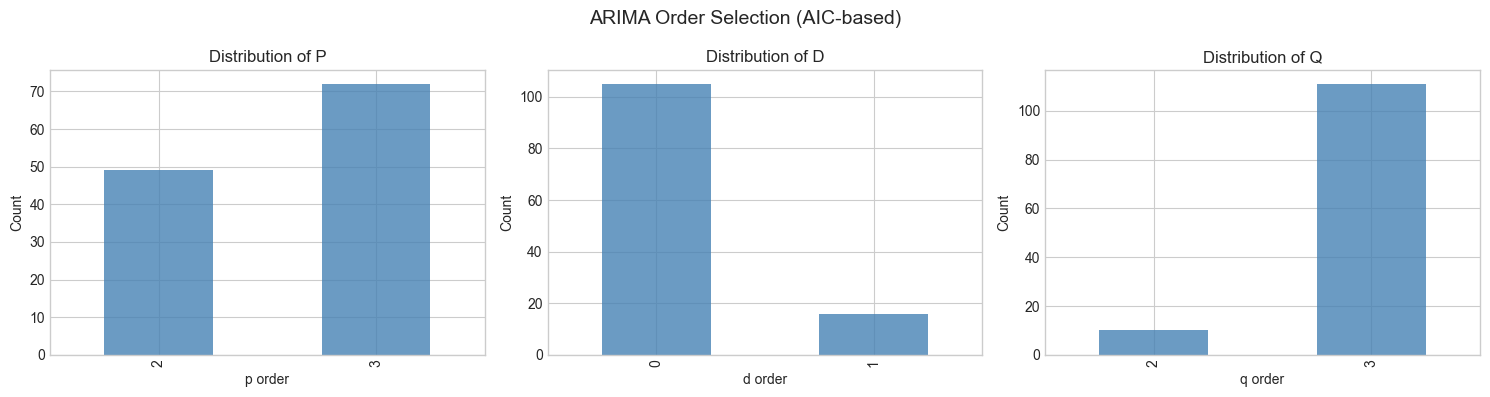


Most common order: [np.float64(3.0) np.float64(0.0) np.float64(3.0)]
Unique orders: 4


In [9]:
if model.orders:
    orders_df = pd.DataFrame([
        {"ticker": t, "p": o[0], "d": o[1], "q": o[2]}
        for t, o in model.orders.items()
    ])
    
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    
    for i, param in enumerate(["p", "d", "q"]):
        orders_df[param].value_counts().sort_index().plot(kind="bar", ax=axes[i], color="steelblue", alpha=0.8)
        axes[i].set_title(f"Distribution of {param.upper()}")
        axes[i].set_xlabel(f"{param} order")
        axes[i].set_ylabel("Count")
    
    plt.suptitle("ARIMA Order Selection (AIC-based)", fontsize=14)
    plt.tight_layout()
    plt.show()
    
    print(f"\nMost common order: {orders_df.mode().iloc[0][['p','d','q']].values}")
    print(f"Unique orders: {len(orders_df.groupby(['p','d','q']))}")

## Step 5 — Prediction Analysis

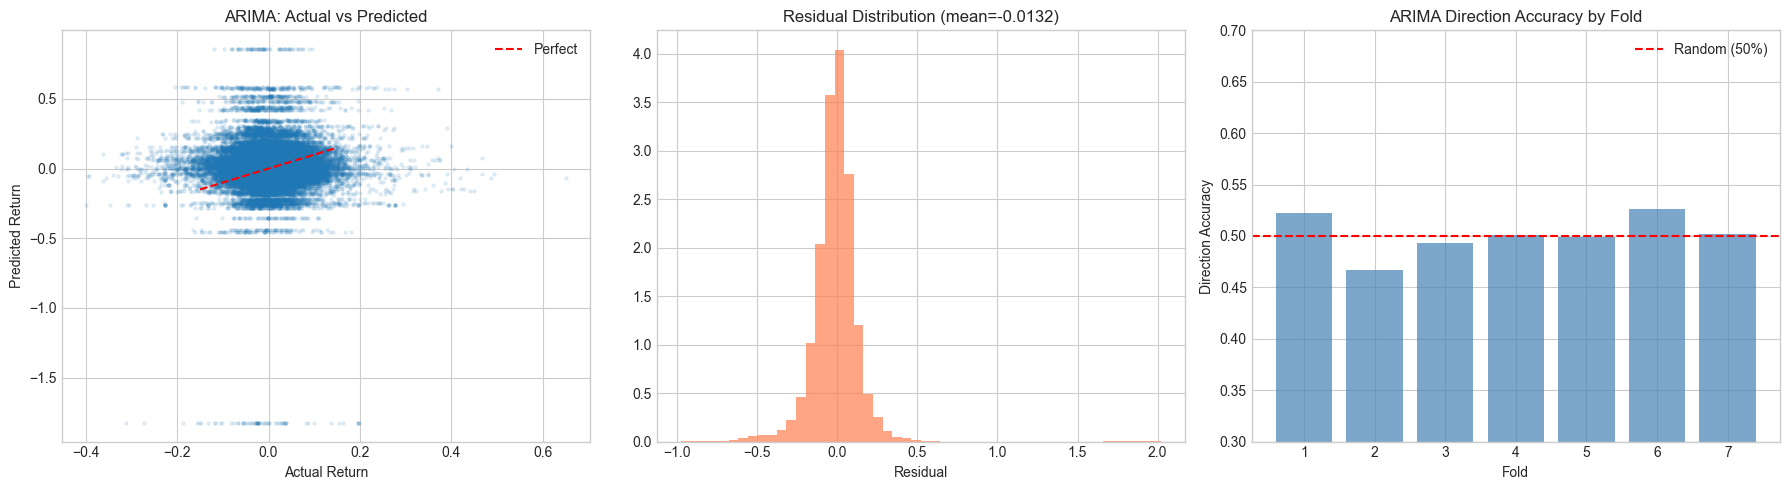

In [10]:
if fold_predictions:
    all_preds = pd.concat(fold_predictions, ignore_index=True)
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # 1. Actual vs Predicted
    axes[0].scatter(all_preds["actual"], all_preds["predicted"], alpha=0.1, s=5)
    axes[0].plot([-0.15, 0.15], [-0.15, 0.15], "r--", label="Perfect")
    axes[0].set_xlabel("Actual Return")
    axes[0].set_ylabel("Predicted Return")
    axes[0].set_title("ARIMA: Actual vs Predicted")
    axes[0].legend()
    
    # 2. Residual distribution
    residuals = all_preds["actual"] - all_preds["predicted"]
    axes[1].hist(residuals, bins=50, density=True, alpha=0.7, color="coral")
    axes[1].set_xlabel("Residual")
    axes[1].set_title(f"Residual Distribution (mean={residuals.mean():.4f})")
    
    # 3. Direction accuracy by fold
    axes[2].bar(results_df["fold"], results_df["direction_accuracy"],
                color="steelblue", alpha=0.7)
    axes[2].axhline(0.5, color="red", linestyle="--", label="Random (50%)")
    axes[2].set_xlabel("Fold")
    axes[2].set_ylabel("Direction Accuracy")
    axes[2].set_title("ARIMA Direction Accuracy by Fold")
    axes[2].legend()
    axes[2].set_ylim(0.3, 0.7)
    
    plt.tight_layout()
    plt.show()

## Step 6 — Save Model & Predictions

In [11]:
# Save the last fold's model
model.save(MODELS_DIR / "arima_model.joblib")
print(f"✅ ARIMA model saved to {MODELS_DIR / 'arima_model.joblib'}")

# Save OOF predictions for ensemble stacking
if fold_predictions:
    all_preds = pd.concat(fold_predictions, ignore_index=True)
    all_preds.to_parquet(DATA_DIR / "processed" / "arima_predictions.parquet")
    print(f"✅ Predictions saved ({len(all_preds):,} samples)")
    print(f"   Avg direction accuracy: {results_df['direction_accuracy'].mean():.1%}")

gc.collect()
print("\n✅ ARIMA training complete!")

  Saved arima (121 tickers) to /Users/anto/Trading_Project/masters_trading_ai/models/arima_model.joblib
✅ ARIMA model saved to /Users/anto/Trading_Project/masters_trading_ai/models/arima_model.joblib
✅ Predictions saved (50,552 samples)
   Avg direction accuracy: 50.2%

✅ ARIMA training complete!


## ✅ ARIMA Training Complete!

**Key takeaways:**
- ARIMA is a univariate statistical baseline — it models each ticker independently
- Auto-selected (p,d,q) orders via AIC for each ticker
- Predictions will have **very low correlation** with ML models (good for ensemble)
- Even moderate direction accuracy (>50%) adds value via diversification

**Next:** Proceed to **Notebook 06 — GARCH Volatility Model**

---
*Educational project. Not financial advice.*